In [1]:
import numpy as np
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import matplotlib.pyplot as plt
import warnings
from typing import List
import qutip as qt
from scipy.interpolate import interp1d
from scipy.constants import Planck
import cvxpy as cp
import random

warnings.filterwarnings("ignore", category=DeprecationWarning)

# Style

plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.frameon'] = False

In [2]:
def covariance_matrix(usb_arr, modes):
    V = np.zeros((len(usb_arr), 2 * len(modes), 2 * len(modes)))
    for part_idx in range(len(usb_arr)):
        real_part = np.real(usb_arr[part_idx])
        imag_part = np.imag(usb_arr[part_idx])
        coord_arr = [(real_part[:, v], imag_part[:, v]) for v in range(len(modes))]
        coord_arr = np.concatenate(coord_arr, axis=0)
        V[part_idx] = np.cov(coord_arr)
    return V

def covariance_matrix2(usb_arr):
    real_part = np.real(usb_arr)
    imag_part = np.imag(usb_arr)

    # Stack quadratures: [Re0, Im0, Re1, Im1, ...]
    xp_mat = np.empty((usb_arr.shape[0], usb_arr.shape[1]*2))
    xp_mat[:, 0::2] = real_part
    xp_mat[:, 1::2] = imag_part

    # Covariance over samples
    return np.cov(xp_mat, rowvar=False)

### ROTATION ###
def cov_rotation(cov_mat, theta):
    """Rotate covariance matrix by angle theta (radians)"""
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(
        [[c, -s],
        [s, c]]
    )
    
    N = cov_mat.shape[0] // 2
    R_big = np.zeros((2*N, 2*N))
    for i in range(N):
        R_big[2*i:2*i+2, 2*i:2*i+2] = R
    
    return R_big @ cov_mat @ R_big.T


def plot_cov_matrix(V, modes, zmax_, zmin_, figure, axis):
    listI = ['$I_{' + str(i - len(modes) // 2) + '}$' for i in range(len(modes))]
    xlabels = np.arange(-1, 2 * len(modes), 2)
    ylabels = np.arange(0, 2 * len(modes), 2)
    x = np.arange(-1, 2 * len(modes) - 1, 1)
    grid_arr = np.arange(0.5, 2 * len(modes) + 0.5, 1)

    a = axis.pcolormesh(x, x, np.flipud(V), shading='nearest', cmap='RdBu_r', vmax=zmax_, vmin=zmin_)
    figure.colorbar(a, aspect=50, label='Signal amplitude [photons]')
    # plt.xticks(xlabels[::4], listI[::4])
    # plt.yticks(ylabels[::2], np.flipud(listI)[::2])
    # axis.set_xticks(grid_arr[0::2], minor=True)
    # axis.set_yticks(grid_arr[0::2], minor=True)
    # axis.grid(True, which='minor', axis='both', linestyle='-', color='w', linewidth=2)


def symplecticity_test(mat):
    S = mat + 0.5j * symp_mat
    eigenvalues, eigenvectors = np.linalg.eig(S)
    return eigenvalues, eigenvectors

verbose = True

fs_to_V2 = 0.45825089808266056

In [3]:
# Load calibration data - G, n
file_calib = r'/media/nanophys-meas/DR_BACKUP/Planck Spectroscopy 2026-04/LKIPA/Planck-Data/planck_2026-04.hdf5'


with h5py.File(file_calib, "r") as dataset:
    sample_grp = dataset
    myrun = list(sample_grp.keys())[0]
    run_grp = sample_grp[myrun]

    # Frequency array
    freq_arr_c = np.asarray(run_grp['freq arr'])

    # Gain and added number of photons (n)
    gain_c = np.asarray(run_grp['gain'])
    n_c = np.asarray(run_grp['n'])
    
    # Gain and added number of photons standard deviations
    gain_std_c = np.asarray(run_grp['std gain'])
    n_std_c = np.asarray(run_grp['std n'])

indices = np.concatenate(
    (
         np.arange(0, 80),
        np.arange(110, 191)
    )
)

freq_arr_c = freq_arr_c[indices]
gain_c = gain_c[indices]
n_c = n_c[indices]
gain_std_c = gain_std_c[indices]
n_std_c = n_std_c[indices]

In [4]:
# Load covariance pump sweep data

folder  = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-04/Covariance/'
file = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]

file = os.path.join(folder, file)

# file = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-04/Covariance/2026-04-14_15_05_45.hdf5'

with h5py.File(file, 'r') as dataset:
    run = list(dataset.keys())[0]
#    meas_type = list(dataset[meas_type].keys())[0]
    amp_pump = np.sort(dataset['{}'.format(run)].attrs['amp_pump'])

  0%|                                                     | 0/2 [00:00<?, ?it/s]

Processing pump amplitude: 0.0
Experimental Cov Mat computed
Quantum Cov Mat computed


 50%|██████████████████████                      | 1/2 [03:03<03:03, 183.45s/it]

Processing pump amplitude: 0.04
Experimental Cov Mat computed
Quantum Cov Mat computed


100%|████████████████████████████████████████████| 2/2 [06:11<00:00, 185.80s/it]


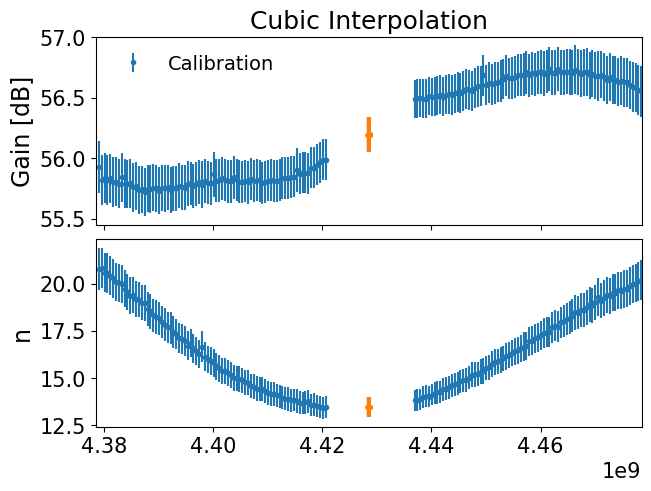

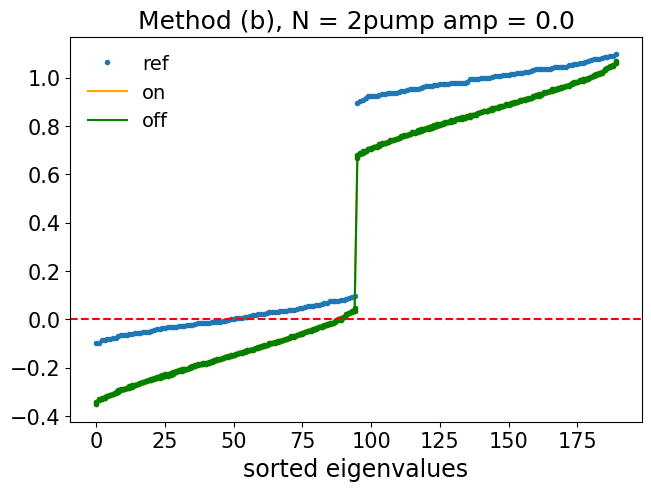

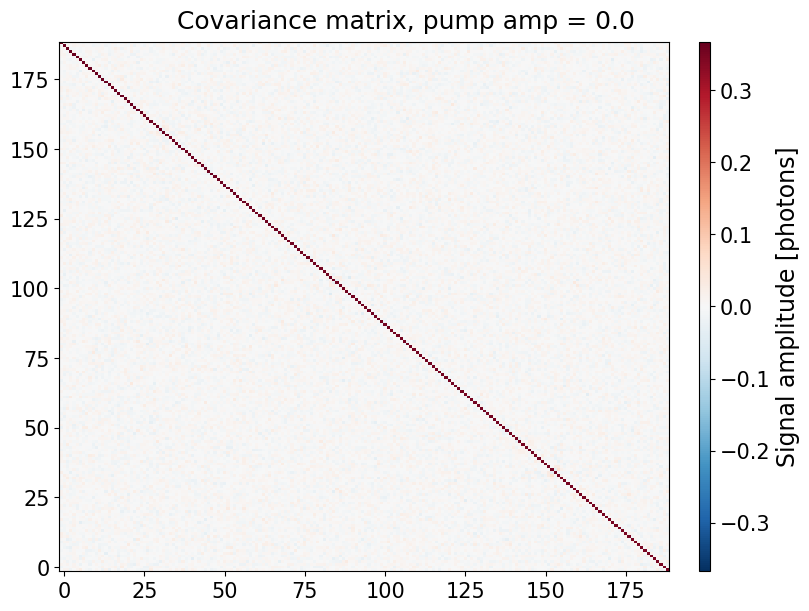

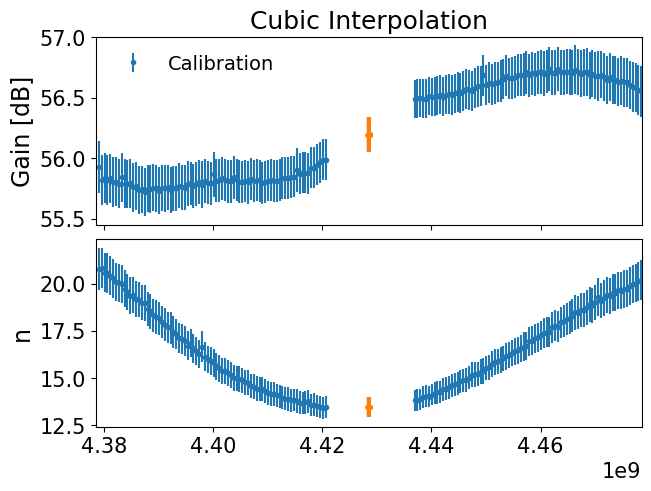

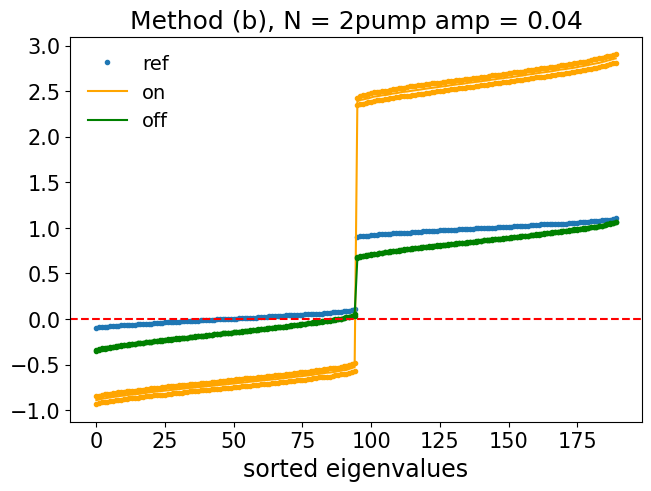

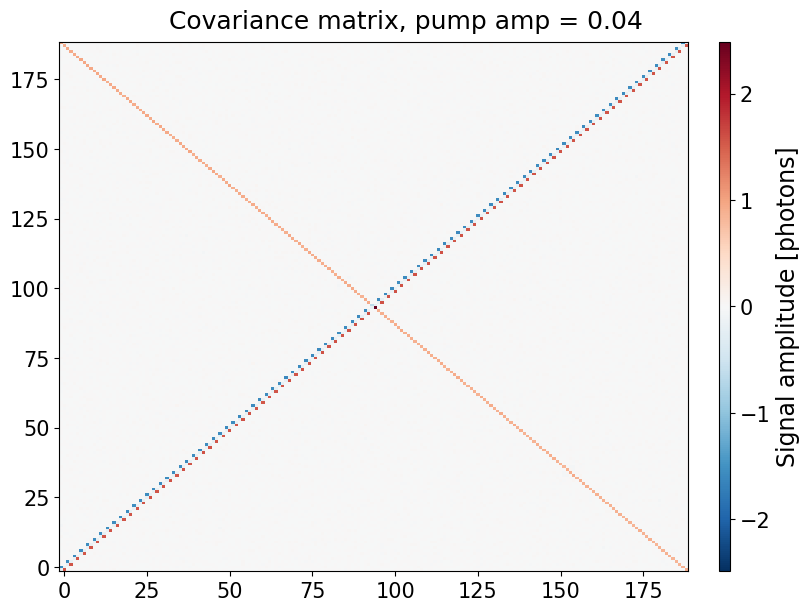

In [5]:

with tqdm(total=(len(amp_pump)), ncols=80) as pbar:
    for pump_amp_idx in range(len(amp_pump)):

        print('Processing pump amplitude: ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        idx_str = '{}/{}'.format(run, pump_amp_idx)
        attr_str = '{}'.format(run)
        # Open hdf5 file
        with h5py.File(file, 'r') as dataset:
            # Data
            freq_arr = np.asarray(dataset[idx_str]['freq comb'])
            usb_on_arr = np.asarray(dataset[idx_str]['USB ON'])
            usb_off_arr = np.asarray(dataset[idx_str]['USB OFF'])
            df = dataset[attr_str].attrs['df']
            Npixels = dataset[attr_str].attrs['Npixels'] #// 2


        # data in V2 (norm factor extracted from calibration)
        usb_on_V = usb_on_arr * np.sqrt(0.56) #np.sqrt(0.458256391393494)
        usb_off_V = usb_off_arr * np.sqrt(0.56) #np.sqrt(0.458256391393494)

        # Symplectic matrix
        J_matrix = np.array([[0, 1], [-1, 0]])
        symp_mat = np.block([[(J_matrix if v == j else np.zeros_like(J_matrix, dtype=complex))
                            for v in range(len(freq_arr))] for j in range(len(freq_arr))])

        # Number of points per chunks (or partitions) of the raw sideband data 
        # experimental chunking = 1000 pts/chunk 
        pts_chunk = 1_000_000
        usb_on_chunked = np.array([usb_on_V[i * pts_chunk:(i + 1) * pts_chunk, :] for i in
                                range((len(usb_on_arr[:, 0]) + pts_chunk - 1) // pts_chunk)])
        usb_off_chunked = np.array([usb_off_V[i * pts_chunk:(i + 1) * pts_chunk, :] for i in
                                range((len(usb_off_arr[:, 0]) + pts_chunk - 1) // pts_chunk)])

        # Conversion of the txperimental covariance matrix from V2 to photon number
        Zc = 50
        # Calculate the square roots of the frequencies, considering the way they are accessed
        sqrt_freqs = np.sqrt(freq_arr[np.arange(2 * len(freq_arr)) // 2])
        # The denominator is a combination of the conversion factor and the square roots of the frequency combinations
        # We need to reshape sqrt_freqs for broadcasting to match the shapes for element-wise division
        conv_factor = Zc * df * Planck * sqrt_freqs[:, np.newaxis] * sqrt_freqs

        # data in sqrt(n)
        usb_on_chunked_n = usb_on_chunked / np.sqrt(Zc * df * Planck * freq_arr)
        usb_off_chunked_n = usb_off_chunked / np.sqrt(Zc * df * Planck * freq_arr)

        # Mean experimental in photon number
        usb_on_coord_arr = [(np.real(usb_on_chunked_n)[0,   :, v], np.imag(usb_on_chunked_n)[0, :, v]) for v in range(len(freq_arr))]
        usb_on_coord_arr = np.concatenate(usb_on_coord_arr, axis=0)
        usb_off_coord_arr = [(np.real(usb_off_chunked_n)[0, :, v], np.imag(usb_off_chunked_n)[0, :, v]) for v in range(len(freq_arr))]
        usb_off_coord_arr = np.concatenate(usb_off_coord_arr, axis=0)

        Mexp_on = np.mean(usb_on_coord_arr, axis=1)
        Mexp_off = np.mean(usb_off_coord_arr, axis=1)

        # Covariance matrix experimental in photon number
        #Vexp_on = covariance_matrix(usb_arr=usb_on_chunked, modes = freq_arr)
        Vexp_on = covariance_matrix(usb_arr=usb_on_chunked, modes=freq_arr) / conv_factor
        Vexp_off = covariance_matrix(usb_arr=usb_off_chunked, modes=freq_arr) / conv_factor

        if verbose:
            print('Experimental Cov Mat computed')

        ##############################################################################
        # INTERPOLATION OF THE GAIN AND ADDED PHOTON NUMBER AT OPERATIONAL FREQUENCIES
        ##############################################################################

        # Interpolation gain function
        f_gain = interp1d(freq_arr_c, gain_c, kind='cubic', fill_value="extrapolate")
        # Gain at the measured frequencies
        gain = f_gain(freq_arr)
        # Interpolation n function
        f_n = interp1d(freq_arr_c, n_c, kind='zero', fill_value="extrapolate")
        # n at the measured frequencies
        n = f_n(freq_arr)

        # ERRORS
        # Gain of the signal error bars
        f_gain_up = interp1d(freq_arr_c, gain_c + gain_std_c, kind='cubic', fill_value="extrapolate")
        gain_up = f_gain_up(freq_arr)
        f_gain_down = interp1d(freq_arr_c, gain_c - gain_std_c, kind='cubic', fill_value="extrapolate")
        gain_down = f_gain_down(freq_arr)
        gain_std = (gain_up - gain_down) / 2
        # n error bars
        f_n_up = interp1d(freq_arr_c, n_c + n_std_c, kind='cubic', fill_value="extrapolate")
        n_up = f_n_up(freq_arr)
        f_n_down = interp1d(freq_arr_c, n_c - n_std_c, kind='cubic', fill_value="extrapolate")
        n_down = f_n_down(freq_arr)
        n_std = (n_up - n_down) / 2
        # correlated errors between G and n (they come from the same fit)
        #f_gn = interp1d(freq_arr_c, gn_corr_c,  kind='cubic', fill_value="extrapolate")
        # Gain at the measured frequencies
        #gn_corr = f_gn(freq_arr)

        ################ Plot of the gain and n #########################
        fig, ax = plt.subplots(2, 1, sharex=True)
        ax[0].errorbar(freq_arr_c, gain_c, yerr=gain_std_c, fmt='.', label='Calibration')
        ax[0].errorbar(freq_arr, gain, yerr=gain_std, fmt='.')
        ax[0].set_ylabel('Gain [dB]')
        ax[0].set_title('Cubic Interpolation')
        ax[1].errorbar(freq_arr_c, n_c, yerr=n_std_c, fmt='.', label='Calibration')
        ax[1].errorbar(freq_arr, n, yerr=n_std, fmt='.')
        ax[1].set_xlim(np.min(freq_arr)-0.05e9, np.max(freq_arr)+0.05e9)
        ax[1].set_ylabel('n')
        ax[0].legend()

        ##############################################################################
        # RECONSTRUCTION OF THE MEAN
        ##############################################################################

        G = np.diag(np.diag(10 ** (np.repeat(gain, 2, axis=0) / 10)))
        Mq_on = Mexp_on / np.sqrt(G)
        Mq_off = Mexp_off / np.sqrt(G)

        ##############################################################################
        # RECONSTRUCTION OF THE COVARIANCE MATRIX
        ##############################################################################

        # indices of the diagonal 
        rows, cols = np.diag_indices_from(Vexp_on[0])

        # METHOD (a) Vq = G^{-1/2} * Vexp * G^{-1/2} - (n + 1/2)

        # Matrix building
        # G (gain) matrix
        G = np.diag(10 ** (np.repeat(gain, 2, axis=0) / 10))
        # G^{-1/2}: two-sided gain correction (correct for covariance matrices)
        G_sqrt_inv = np.diag(1.0 / np.sqrt(np.diag(G)))
        # N (added number of photons) matrix
        n_xp = np.repeat(n, 2, axis=0)
        N = np.diag(n_xp)

        # Quantum covariance matrices
        Vq_on_a = G_sqrt_inv @ Vexp_on @ G_sqrt_inv - (N + 1 / 2 * np.identity(len(N)))
        Vq_off_a = G_sqrt_inv @ Vexp_off @ G_sqrt_inv - (N + 1 / 2 * np.identity(len(N)))

        # check if quantum cov mat is symplectic
        symp_Vq_on_a, _ = symplecticity_test(Vq_on_a)
        symp_Vq_on_a = np.sort(np.real(symp_Vq_on_a), axis=-1)
        symp_Vq_off_a, _ = symplecticity_test(Vq_off_a)
        symp_Vq_off_a = np.sort(np.real(symp_Vq_off_a), axis=-1)

        # Reference matrix
        mu, sigma = 0.0, np.std(np.triu(Vq_off_a, k=1) + np.tril(Vq_off_a, k=-1))
        Vq_test = mu + sigma * np.random.randn(len(cols), len(rows))
        Vq_test[rows, cols] += np.full_like(Vq_test[0], 0.5)
        symp_Vq_test, _ = symplecticity_test(Vq_test)
        symp_Vq_test = np.sort(np.real(symp_Vq_test))

        # METHOD (b) Vq_off^ii = 1 / (2n+2) * (G^{-1/2} * Vexp * G^{-1/2})^ii
        #            Vq_off^ij = (G^{-1/2} * Vexp * G^{-1/2})^ij
        #            Vq_on = G^{-1/2} (Vexp_on - Vexp_off) G^{-1/2} + Vq_off

        # Scale pump-off cov matrix by G^{-1/2} from both sides
        Vq_off_b = G_sqrt_inv @ Vexp_off @ G_sqrt_inv
        # Rescale even more the diagonal by 1/(2n+2) to get Quantum cov matrix in photon number
        Vq_off_b[:, rows, cols] = 1 / (2 * n_xp + 2) * np.diagonal(Vq_off_b, axis1=1, axis2=2)

        # Calculate the pump-on quantum cov matrix as
        Vq_on_b = G_sqrt_inv @ (Vexp_on - Vexp_off) @ G_sqrt_inv  + Vq_off_b
        #Vq_on_b = Vexp_on
        # check if quantum cov mat is symplectic
        symp_Vq_on_b, _ = symplecticity_test(Vq_on_b)
        symp_Vq_on_b = np.sort(np.real(symp_Vq_on_b), axis=-1)
        symp_Vq_off_b, _ = symplecticity_test(Vq_off_b)
        symp_Vq_off_b = np.sort(np.real(symp_Vq_off_b), axis=-1)

        # Reference matrix
        mu, sigma = np.mean(np.triu(Vq_off_b, k=1) + np.tril(Vq_off_b, k=-1)), np.std(np.triu(Vq_off_b, k=1) + np.tril(Vq_off_b, k=-1))
        Vq_test = mu + sigma * np.random.randn(len(cols), len(rows))
        Vq_test[rows, cols] += np.full_like(Vq_test[0], 0.5)
        symp_Vq_test, _ = symplecticity_test(Vq_test)
        symp_Vq_test = np.sort(np.real(symp_Vq_test))

        if verbose:
            print('Quantum Cov Mat computed')


        # ERROR ANALYSIS (check notes for derivation)
        # Matrix building
        sG = np.diag(10 ** (np.repeat(gain_std, 2, axis=0) / 10))
        sn = np.diag(np.repeat(n_std, 2, axis=0))
        #sGn = np.diag(np.repeat(gn_corr, 2, axis=0))

        sVexp_on = np.std(Vexp_on, axis=0)**2
        sVexp_off = np.std(Vexp_off, axis=0)**2

        # Errors (error in n is the main source of error by few orders of magnitude)
        e_G = (G_sqrt_inv @ G_sqrt_inv @ (Vexp_on - Vexp_off) @ G_sqrt_inv @ sG @ G_sqrt_inv)**2
        e_Vexp_on = (G_sqrt_inv @ sVexp_on @ G_sqrt_inv)**2
        e_Vexp_off = (G_sqrt_inv @ (-sVexp_off) @ G_sqrt_inv)**2

        # off-diagonal errors
        e_Vq_off = ((G_sqrt_inv @ G_sqrt_inv @ Vexp_off @ G_sqrt_inv @ sG @ G_sqrt_inv)**2 +
                    (G_sqrt_inv @ sVexp_off @ G_sqrt_inv)**2)

        # diagonal errors
        e_Vq_off[:, rows, cols] = np.diagonal(
                                            (G_sqrt_inv @ G_sqrt_inv @ (1 / (2 * n_xp + 2) * Vexp_off) @ G_sqrt_inv @ sG @ G_sqrt_inv)**2 +
                                            (G_sqrt_inv @ (1 / (2 * n_xp + 2) * sVexp_off) @ G_sqrt_inv)**2 +
                                            (G_sqrt_inv @ (1 / (2 * (n_xp + 1)**2) * Vexp_off) @ G_sqrt_inv @ sn)**2,
                                            axis1=-2, axis2=-1)
#        e_Gn = 2 * np.matmul(np.matmul(np.linalg.inv(G**2), 1 / (2 * n_xp + 2) * Vexp_off), 
#                            np.matmul(np.linalg.inv(G), 1 / (2 * (n_xp + 1)**2) * Vexp_off)) * sGn

        sVq_on_b = np.sqrt(e_G + e_Vexp_on + e_Vexp_off + e_Vq_off)# + e_Gn)
        sVq_off_b = np.sqrt(e_Vq_off + e_Vexp_off)

        # Compute symplecticity test considering errors (don't think it says a lot)
        Vq_on_b_emax = Vq_on_b + sVq_on_b
        Vq_on_b_emin = Vq_on_b - sVq_on_b

        symp_Vq_on_b_emax, _ = symplecticity_test(Vq_on_b_emax)
        symp_Vq_on_b_emax = np.sort(np.real(symp_Vq_on_b_emax), axis=-1)
        symp_Vq_on_b_emin, _ = symplecticity_test(Vq_on_b_emin)
        symp_Vq_on_b_emin = np.sort(np.real(symp_Vq_on_b_emin), axis=-1)


        ####################### Plot the eigenvalues mean through all the chuncks #########################
        fig, ax = plt.subplots(1)
        ax.plot(symp_Vq_test, '.', label='ref')
        ax.plot(symp_Vq_on_b.T, '.', c='orange')
        ax.plot(np.mean(symp_Vq_on_b, axis=0), '-', c='orange', label='on')
#        ax.plot(np.mean(symp_Vq_on_b_emax, axis=0)[1:-1], '--', c='darkorange')
#        ax.plot(np.mean(symp_Vq_on_b_emin, axis=0)[1:-1], '--', c='darkorange')
        ax.plot(symp_Vq_off_b.T, '.', c='green')
        ax.plot(np.mean(symp_Vq_off_b, axis=0), '-', c='green', label='off')
        # ax.plot(symp_Vq_norm_b.T, '.', c='purple')
        # ax.plot(np.mean(symp_Vq_norm_b, axis=0), '-', c='purple', label='norm')
        ax.axhline(0, c='red', ls='--')
        ax.set_title('Method (b), N = '+ str(int(len(usb_on_arr) / pts_chunk)) + 'pump amp = ' + str(np.round(amp_pump[pump_amp_idx], 3)))
        ax.set_xlabel('sorted eigenvalues')
        ax.legend()

        ########################### Covariance matrix plot ##############################
        zmax = np.max(Vq_on_b[0])
        zmin = -zmax
        fig, ax = plt.subplots(1, figsize=(8, 6))
        #plot_cov_matrix(Vq_on_b[random.randint(0, len(Vq_on_b)-1)], freq_arr, zmax, zmin, fig, ax)
        plot_cov_matrix(Vq_on_b[0], freq_arr, zmax, zmin, fig, ax)
        fig.suptitle('Covariance matrix, pump amp = ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        # save data in hdf5 file
        save = False

        if save:
            
            with h5py.File(file, 'a') as dataset:
                # String as handles
                Vexp_on_data_str = "{}/Vexp on".format(idx_str)
                Vq_on_data_str = "{}/Vq on".format(idx_str)
                #Vp_on_data_str = "{}/Vp on".format(idx_str)
                std_Vq_on_data_str = "{}/sVp on".format(idx_str)
                Mq_on_data_str = "{}/meanq on".format(idx_str)

                # Attribute str of the "chunk" folder
                attr_chunk_str = '{}'.format(idx_str)

                Vexp_off_data_str = "{}/Vexp off".format(idx_str)
                Vq_off_data_str = "{}/Vq off".format(idx_str)
                #Vp_off_data_str = "{}/Vp off".format(idx_str)
                std_Vq_off_data_str = "{}/sVp off".format(idx_str)
                Mq_off_data_str = "{}/meanq off".format(idx_str)

                # Write data to datasets
                dataset.create_dataset(Vexp_on_data_str, (np.shape(Vexp_on[0])),
                                    dtype=float, data=Vexp_on[0])
                dataset.create_dataset(Vq_on_data_str, (np.shape(Vq_on_b[0])),
                                    dtype=float, data=Vq_on_b[0])
                #dataset.create_dataset(Vp_on_data_str, (np.shape(Vp_on)),dtype=float, data=Vp_on)
                dataset.create_dataset(std_Vq_on_data_str, (np.shape(sVq_on_b)),
                                    dtype=float, data=sVq_on_b)
                dataset.create_dataset(Mq_on_data_str, (np.shape(Mq_on)),
                                        dtype=float, data=Mq_on)
                
                dataset.create_dataset(Vexp_off_data_str, (np.shape(Vexp_off[0])),
                                    dtype=float, data=Vexp_off[0])
                dataset.create_dataset(Vq_off_data_str, (np.shape(Vq_off_b[0])),
                                    dtype=float, data=Vq_off_b[0])
                dataset.create_dataset(std_Vq_off_data_str, (np.shape(sVq_off_b)),
                                    dtype=float, data=sVq_off_b)
                dataset.create_dataset(Mq_off_data_str, (np.shape(Mq_off)),
                                        dtype=float, data=Mq_off)


                # Write dataset attributes
                dataset[attr_chunk_str].attrs["N chunks"] = int(len(usb_on_arr) / pts_chunk)
                dataset[Vexp_on_data_str].attrs["Unit"] = "n"
                dataset[Vq_on_data_str].attrs["Unit"] = "n"

                if verbose:
                    print('cov matrices saved')
        

        pbar.update(1)

plt.show()

# TESTING
----

## T.1 Raw covariance

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Pixelization for easier processing

PIXELS = int(5e5)

### RAW COVARIANCE ##
V_raw_off = np.zeros((2 * len(freq_arr), 2*len(freq_arr)))
V_raw_on = np.zeros_like(V_raw_off)

for i in range (Npixels//PIXELS):

    usb_off_scaled = usb_off_arr[i * PIXELS : (i + 1) * PIXELS]* np.sqrt(0.56/ (freq_arr * Zc * df * Planck))
    usb_on_scaled = usb_on_arr[i * PIXELS : (i + 1) * PIXELS]* np.sqrt(0.56/ (freq_arr * Zc * df * Planck))

    V_raw_off += covariance_matrix2(usb_off_scaled)
    V_raw_on += covariance_matrix2(usb_on_scaled)


### PUMP OFF COVARIANCE IN PHOTON NUMBER ###
# DE-AMPLIFICATION
V_deamp_off = G_sqrt_inv @ V_raw_off @ G_sqrt_inv

# REMOVE ADDED PHOTONS
V_photons_off = V_deamp_off / (2 * N + 2) # - (N + 1/2 * np.identity(len(N))) # 

### PUMP ON COVARIANCE IN PHOTON NUMBER ###
V_photons_on =  (G_sqrt_inv @ (V_raw_on - V_raw_off  ) @ G_sqrt_inv)+ V_photons_off #

In [7]:
theta = 0.25*np.pi
plot = cov_rotation(V_photons_on, theta)

vmax = np.max(plot) * 1.2
vmin = -vmax

In [8]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Define colors
color_a = '#9d6108'  # Example: Red
color_b = '#12776f'  # Example: Blue
color_c = '#a9ccc7'

# style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['font.size'] = 14
plt.rcParams['legend.fontsize'] = 17
plt.rcParams['legend.frameon'] = False

# Create custom colormap
cmap_name = 'my_list'
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, [color_a, color_c, color_b])

# Load PSD data
psd_list = np.loadtxt('/home/nanophys-meas/Desktop/Jai Master Thesis/Presto-Measurement-Scripts/LKIPA Measurements/Time series data/LKIPA-PSD-df=100khz-pixels=20000.txt')

# Frequency array for PSD
df = 100e3  # Frequency resolution in Hz
n_samples = len(psd_list)
freq_arr_psd = np.arange(n_samples) * df

# Freq range of interest
f_min = 0.425e9  # 0.42 GHz
f_max = 0.435e9  # 0.44 GHz
indices = np.arange(f_min/1e5, f_max/1e5).astype(int)

freq_band =  4 + freq_arr_psd[indices]/1e9
psd_band = psd_list[indices]

[Text(0, 14.5, '-40'),
 Text(0, 34.5, '-30'),
 Text(0, 54.5, '-20'),
 Text(0, 74.5, '-10'),
 Text(0, 94.5, '0'),
 Text(0, 114.5, '10'),
 Text(0, 134.5, '20'),
 Text(0, 154.5, '30'),
 Text(0, 174.5, '40')]

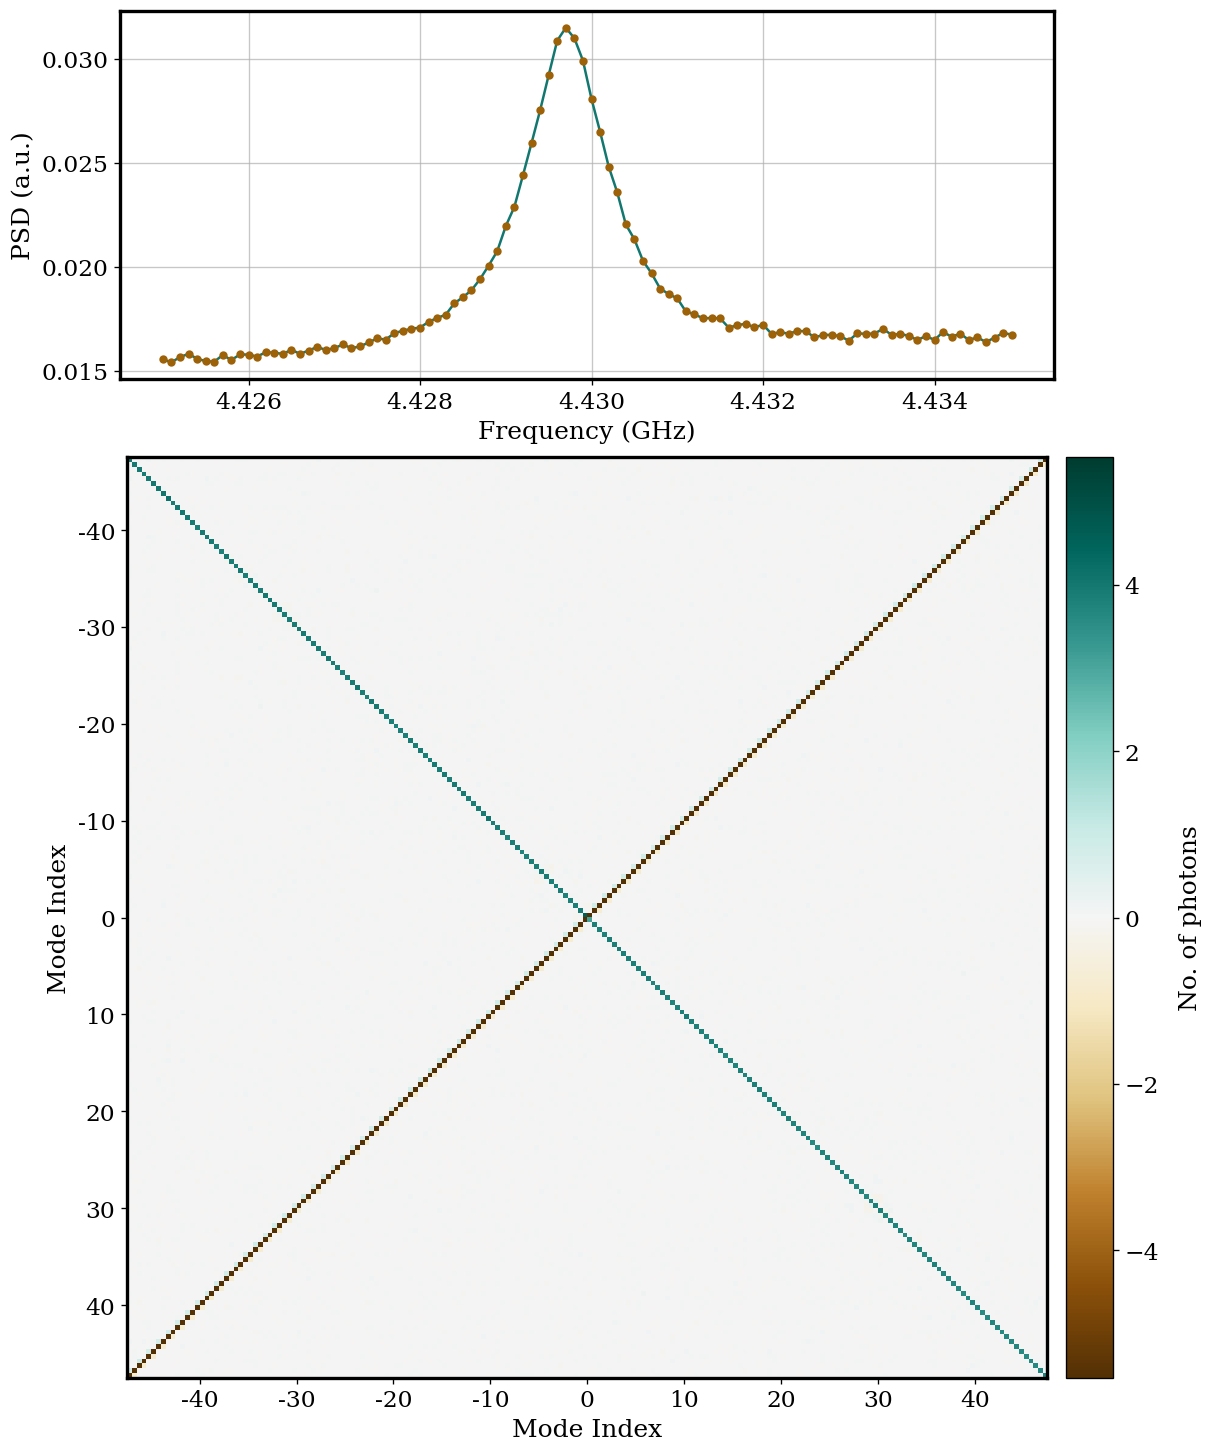

In [9]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 12), dpi=120)

# Two columns: main plot area | thin colorbar column
# Dummy axis in gs[0, 1] keeps the PSD row the same width as the cov + colorbar row
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.5], width_ratios=[20, 1])

ax_psd   = fig.add_subplot(gs[0, 0])
ax_cov   = fig.add_subplot(gs[1, 0])
cax      = fig.add_subplot(gs[1, 1])
ax_dummy = fig.add_subplot(gs[0, 1])
ax_dummy.axis('off')

# ── Row 0: PSD ────────────────────────────────────────────────────────────────
ax_psd.plot(freq_band, psd_band, color=color_b, marker='o', ms=4, mfc=color_a, mec=color_a)
ax_psd.set_xlabel('Frequency (GHz)')
ax_psd.set_ylabel('PSD (a.u.)')
ax_psd.grid(alpha=0.7)
for spine in ax_psd.spines.values():
    spine.set_linewidth(2)

# ── Row 1: Covariance matrix ─────────────────────────────────────────────────
im = ax_cov.imshow(
    plot,
    aspect='equal',
    cmap='BrBG',
    origin='upper',
    vmax=vmax,
    vmin=vmin,
)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label('No. of photons', labelpad=12)

ax_cov.set_xlabel("Mode Index")
ax_cov.set_ylabel("Mode Index")
for spine in ax_cov.spines.values():
    spine.set_linewidth(2)

modes = len(freq_arr)
mode_half = (modes - 1) / 2
step = 10
max_label = (int(mode_half) // step) * step
mode_labels = np.arange(-max_label, max_label + 1, step)
tick_positions = 2 * (mode_labels + mode_half) + 0.5

ax_cov.set_xticks(tick_positions)
ax_cov.set_xticklabels(mode_labels)
ax_cov.set_yticks(tick_positions)
ax_cov.set_yticklabels(mode_labels)


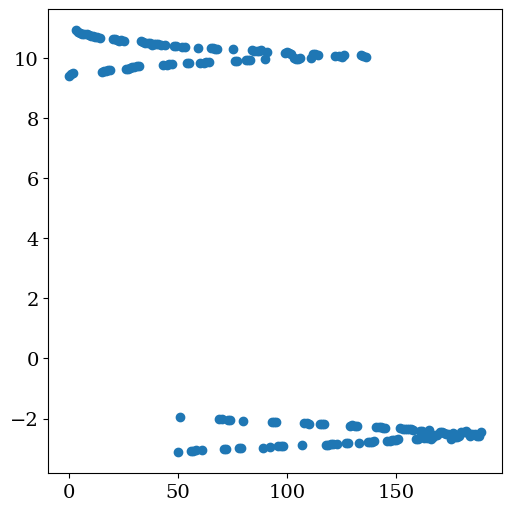

In [13]:
v_eigs = np.linalg.eigvals(V_photons_on)

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(np.arange(2 * len(freq_arr)), v_eigs)
